In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shuvoalok/raf-db-dataset/test_labels.csv
/kaggle/input/datasets/shuvoalok/raf-db-dataset/train_labels.csv
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2941_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2717_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2499_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2724_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2935_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2419_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2779_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2566_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2805_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2495_aligned.jpg
/kaggle/input/dataset

In [2]:
# ==================================================
# Import required libraries
# ==================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model

from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D)

from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
# ==================================================
# Dataset paths
# ==================================================

DATASET_PATH = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET"
TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")
print(TRAIN_DIR)
print(TEST_DIR)

/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test


In [4]:
# ==================================================
# Hyperparameters
# ==================================================

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15

In [5]:
# ==================================================
# Data augmentation
# ==================================================

train_datagen = ImageDataGenerator(rescale=1./255,
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.2, horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
# ==================================================
# Training generator
# ==================================================

train_generator = train_datagen.flow_from_directory(TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True)

Found 12271 images belonging to 7 classes.


In [7]:
# ==================================================
# Test generator
# ==================================================

test_generator = test_datagen.flow_from_directory(TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False)

Found 3068 images belonging to 7 classes.


In [8]:
# ==================================================
# Check class indices
# ==================================================

print(train_generator.class_indices)

{'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6}


In [9]:
emotion_map = {0: "Surprise",
    1: "Fear",
    2: "Disgust",
    3: "Happy",
    4: "Sad",
    5: "Angry",
    6: "Neutral"}

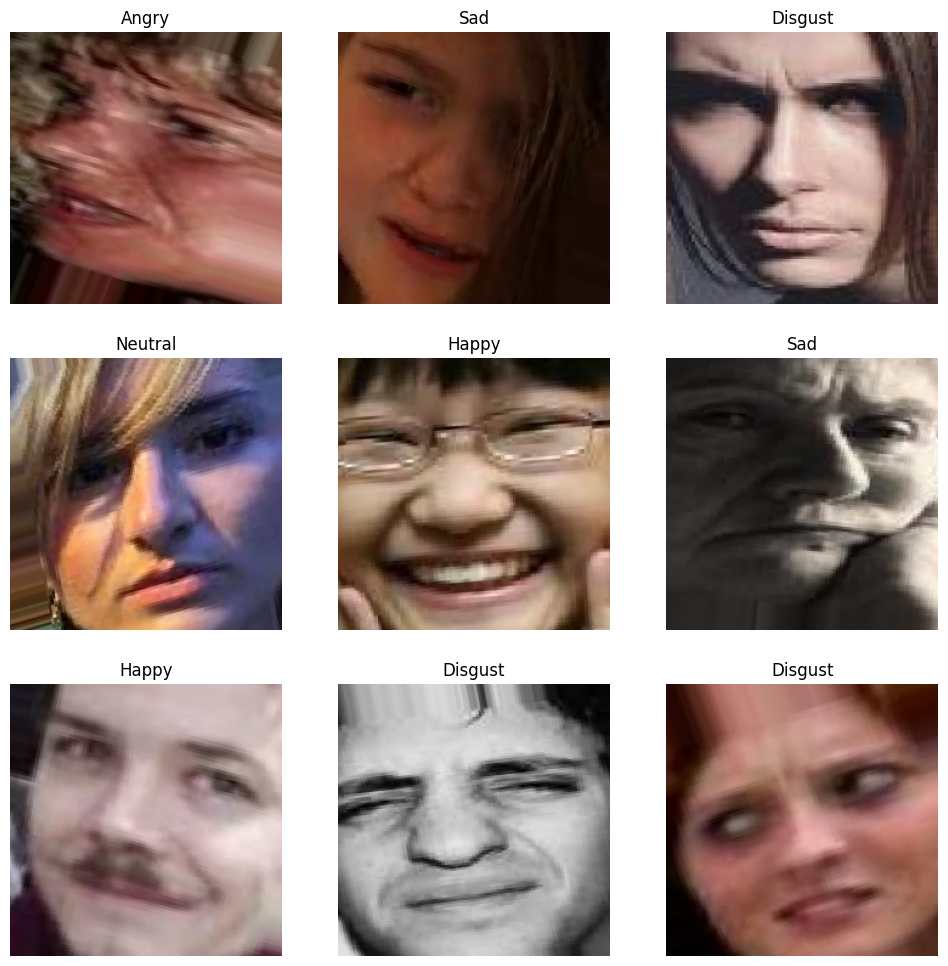

In [10]:
# Visualize dataset

images, labels = next(train_generator)

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(emotion_map[np.argmax(labels[i])])
    plt.axis("off")

plt.show()

## MobileNetV2 Model

In [11]:
from tensorflow.keras.applications import MobileNetV2

In [12]:
# ==================================================
# Load pretrained MobileNetV2
# ==================================================

base_model = MobileNetV2(weights="imagenet",
    include_top=False, input_shape=(224, 224, 3))

base_model.trainable = False

I0000 00:00:1786074785.961082      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786074785.967742      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
# ==================================================
# Build classifier
# ==================================================

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(7, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,592,839 (9.89 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [14]:
model.compile(optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"])

In [15]:
callbacks = [EarlyStopping(patience=5, restore_best_weights=True),

    ReduceLROnPlateau(factor=0.5, patience=2),

    ModelCheckpoint("best_model.keras", save_best_only=True)]

In [17]:
mobilenet_history = model.fit(train_generator,
    validation_data=test_generator, epochs= EPOCHS, callbacks=callbacks)

Epoch 1/15


2026-08-07 03:56:07.602883: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 03:56:07.740238: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1786074970.596819     303 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 39/384 ━━━━━━━━━━━━━━━━━━━━ 3:02 529ms/step - accuracy: 0.2940 - loss: 2.5413

2026-08-07 03:56:40.883650: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 03:56:41.020304: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.3888 - loss: 2.0610

2026-08-07 04:00:15.737976: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 04:00:15.874422: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


384/384 ━━━━━━━━━━━━━━━━━━━━ 270s 647ms/step - accuracy: 0.4328 - loss: 1.7868 - val_accuracy: 0.5300 - val_loss: 1.2790 - learning_rate: 0.0010
Epoch 2/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 151s 393ms/step - accuracy: 0.5111 - loss: 1.3471 - val_accuracy: 0.5583 - val_loss: 1.2182 - learning_rate: 0.0010
Epoch 3/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 154s 400ms/step - accuracy: 0.5370 - loss: 1.2822 - val_accuracy: 0.5603 - val_loss: 1.2128 - learning_rate: 0.0010
Epoch 4/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 154s 402ms/step - accuracy: 0.5486 - loss: 1.2508 - val_accuracy: 0.5844 - val_loss: 1.1555 - learning_rate: 0.0010
Epoch 5/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 150s 390ms/step - accuracy: 0.5440 - loss: 1.2344 - val_accuracy: 0.5688 - val_loss: 1.1819 - learning_rate: 0.0010
Epoch 6/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 152s 396ms/step - accuracy: 0.5518 - loss: 1.2124 - val_accuracy: 0.5753 - val_loss: 1.1651 - learning_rate: 0.0010
Epoch 7/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 150s 390ms/step - accuracy: 0.5684 

In [18]:
# ==================================================
# Function to plot training history
# ==================================================

def plot_history(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy

    axes[0].plot(history.history["accuracy"])
    axes[0].plot(history.history["val_accuracy"])
    axes[0].set_title(f"{title} Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(["Train", "Validation"]    )

    # Loss

    axes[1].plot(history.history["loss"])
    axes[1].plot(history.history["val_loss"])
    axes[1].set_title(f"{title} Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend(["Train", "Validation"])

    plt.show()

In [19]:
# ==================================================
# Evaluate model
# ==================================================

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
def evaluate_model(model, generator, title):

    predictions = model.predict(generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes
    print("=" * 50)
    print(title)
    print("=" * 50)
    
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 8))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")

    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

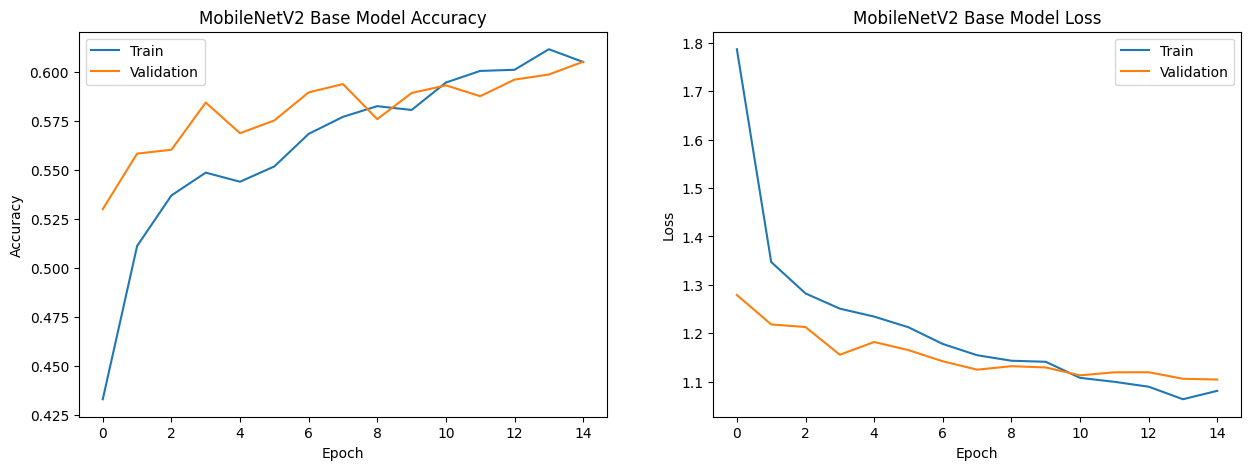

In [20]:
plot_history(mobilenet_history, "MobileNetV2 Base Model")

96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step
MobileNetV2 Base Model
              precision    recall  f1-score   support

           0       0.56      0.40      0.47       329
           1       0.69      0.30      0.42        74
           2       0.28      0.04      0.08       160
           3       0.67      0.84      0.75      1185
           4       0.52      0.55      0.53       478
           5       0.58      0.43      0.49       162
           6       0.55      0.54      0.55       680

    accuracy                           0.61      3068
   macro avg       0.55      0.44      0.47      3068
weighted avg       0.58      0.61      0.58      3068



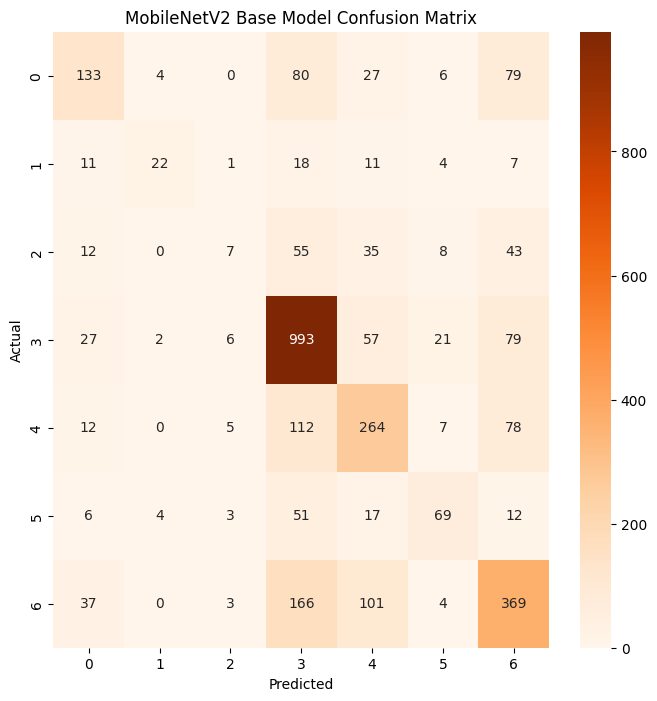

In [21]:
evaluate_model(model, test_generator, "MobileNetV2 Base Model")

## MobileNetV2 Fine-Tuning

In [22]:
base_model.trainable = True

for layer in base_model.layers[:-20]:

    layer.trainable = False

In [23]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy", metrics=["accuracy"])

In [24]:
history_fine = model.fit(train_generator,
    validation_data=test_generator, epochs=10,
    callbacks=callbacks)

Epoch 1/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 182s 430ms/step - accuracy: 0.5326 - loss: 1.2745 - val_accuracy: 0.5675 - val_loss: 1.6015 - learning_rate: 1.0000e-05
Epoch 2/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 153s 398ms/step - accuracy: 0.5584 - loss: 1.1949 - val_accuracy: 0.5880 - val_loss: 1.3534 - learning_rate: 1.0000e-05
Epoch 3/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 150s 390ms/step - accuracy: 0.5764 - loss: 1.1480 - val_accuracy: 0.5994 - val_loss: 1.1934 - learning_rate: 5.0000e-06
Epoch 4/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 149s 388ms/step - accuracy: 0.5864 - loss: 1.1380 - val_accuracy: 0.6010 - val_loss: 1.1300 - learning_rate: 5.0000e-06
Epoch 5/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 150s 390ms/step - accuracy: 0.5933 - loss: 1.1199 - val_accuracy: 0.5988 - val_loss: 1.1123 - learning_rate: 2.5000e-06


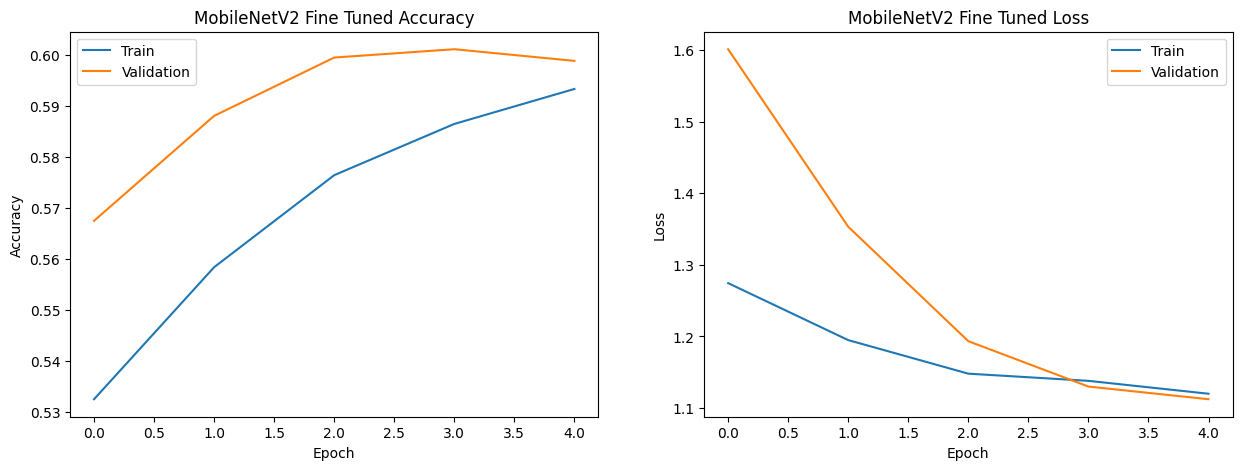

In [25]:
plot_history(history_fine, "MobileNetV2 Fine Tuned")

In [26]:
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step


In [27]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[  87    0    3  141   21    2   75]
 [   8   11    0   41    6    2    6]
 [   4    0   15   76   22    1   42]
 [   9    0    7 1095   20    2   52]
 [   6    0    9  191  209    0   63]
 [   2    2    3  100   18   31    6]
 [  17    0    8  282   78    2  293]]


In [28]:
model.save("emotion_model.keras")